# Corruption accountability at Nepal's Special Court — the full read

This notebook is the **deep companion** to the summary page at
**[jawafdehi.org/research/corruption-accountability](https://jawafdehi.org/research/corruption-accountability)**.
That page is the lite version — eleven charts and the headline story. Here we reproduce every one of
them from the live read-only query API **and go further**: ~18 interactive charts, one **section per
question**, each with the numbers spelled out and the caveats attached.

Charts are **Nepali-first** — labels read `नेपाली (English)` and figures use Devanagari numerals
(`२,८४६`, `४५.१%`, `२०६९/७०`), matching Jawafdehi's house style. The published page is currently
force-rendered English-only, so this is also the Nepali read of the same analysis.

**Corpus.** The Special Court **criminal register**: case number in the `-CR-` register, filed in the
**complete fiscal years BS 2069/70 → 2082/83** (`registration_date_bs` in `[2069-04-01, 2083-04-01)`).
The register *is* the definition — the `-CR-` criminal docket opens at Shrawan 2069, exactly the FY
boundary (the old `93-<yr>-<seq>` scheme ends Ashadh 2069), so the window and the register share one
edge and give **2,949** cases over 14 clean fiscal years. A handful (~34) are individual-plaintiff
review/contempt petitions (`निर्णय वदर`) that live in `-CR-`; they fall in the `other` case-type bucket,
so the **"substantive" corruption cut (2,795)** — which further drops money-laundering and `other` — is
unaffected by them.
*(The published site renders an all-years corpus, so its absolute counts differ slightly from the
FY-window figures below — the shape of every finding is the same.)*

**Interactive.** Everything is **Plotly** — hover for values, click legend entries to toggle a series,
drag to zoom, double-click to reset.

**Data source (auto).** One `dataset/` folder is the single source of truth: `cases.csv` (the 2,949
`-CR-` corpus), `hearings.csv`, `entities.csv`, and `assumptions.csv` (external CIAA constants). The
notebook **derives** every table below from those in pandas — no stored result files, no per-metric SQL.
The committed `dataset/` files **are** the cache: normal runs read them instantly; a refresh re-paginates
the raw `-CR-` pull, re-scopes, and rewrites them (no separate raw copy on disk). First live pull ≈ 40s.
**No credentials are needed to run any of this.** Set `REFRESH_FROM_API = True` only to re-pull from the
live API; that prints a short code to approve in a browser (your account needs the `ReadOnly` role).

In [1]:
# Run this first. Bootstraps Google Colab / any fresh machine: if corpus_data.py isn't already
# here, fetch the committed dataset + data layer from GitHub and install the extra deps, so the
# notebook is self-contained (no credentials — it reads the frozen dataset/ snapshot). A no-op
# when you are already running inside the repo.
import os
if not os.path.exists("corpus_data.py"):
    import subprocess, sys, urllib.request
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "plotly>=6", "nepali-datetime", "pandas"], check=True)
    _RAW = "https://raw.githubusercontent.com/Jawafdehi/corruption-research/main/"
    os.makedirs("dataset", exist_ok=True)
    for _f in ("corpus_data.py", "dataset/cases.csv", "dataset/hearings.csv",
               "dataset/entities.csv", "dataset/assumptions.csv", "dataset/leadership.csv"):
        urllib.request.urlretrieve(_RAW + _f, _f)
    print("Bootstrapped from GitHub: dataset + data layer ready. No credentials needed.")

In [2]:
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import pandas as pd
import corpus_data as cd

REFRESH_FROM_API = False   # True = re-paginate the raw -CR- pull from the API and rewrite dataset/*.csv
pio.templates.default = "plotly_white"
# Static PNG next to each interactive chart so the executed notebook renders on GitHub (which can't
# show interactive Plotly). Needs kaleido; without it (e.g. Colab) keep interactive-only, which Colab,
# JupyterLab and nbviewer all render natively.
try:
    import kaleido  # noqa: F401
    pio.renderers.default = "plotly_mimetype+png"
except ModuleNotFoundError:
    pio.renderers.default = "plotly_mimetype"

# ---- Devanagari numerals + Nepali(English) display labels -------------------
_EN2NE = str.maketrans("0123456789", "०१२३४५६७८९")
def dev(s):
    "Render a value with Devanagari digits (commas/%/decimals preserved)."
    return str(s).translate(_EN2NE)

# Brand + semantic palette.
NAVY, CRIMSON, BLUE, GREEN, AMBER, GRAY = "#0E1F3A", "#B5242C", "#2a78d6", "#1baf7a", "#eda100", "#9aa0a6"

# Outcomes — Nepali(English) labels on a good -> bad status ramp, reused everywhere.
L_CONV, L_PART, L_ACQ = "दोषी ठहर (Convicted)", "आंशिक ठहर (Partial)", "सफाई (Acquitted)"
OUT = {L_CONV: GREEN, L_PART: AMBER, L_ACQ: CRIMSON}

# Charge families — the exact CVD-safe colours the site's ChargeMixByYear uses.
CLR = {"bribery": BLUE, "fake": CRIMSON, "embezzlement": GREEN, "benefit": "#4a3aa7", "loss": AMBER, "other": GRAY}
FAM_NE = {"bribery": "रिसवत/घुस (Bribery)", "fake": "नक्कली प्रमाणपत्र (Fake credential)",
          "embezzlement": "हिनामिना (Embezzlement)", "benefit": "गैरकानुनी लाभ (Illegal benefit)",
          "loss": "हानिनोक्सानी (Loss to govt)", "other": "अन्य (Other)"}
CLR_NE = {FAM_NE[k]: v for k, v in CLR.items()}
NE_MONTHS = ["बैशाख", "जेठ", "असार", "साउन", "भदौ", "असोज", "कात्तिक", "मंसिर", "पुस", "माघ", "फागुन", "चैत"]

# Axis-title constants (Nepali (English)).
AX_FY   = "आर्थिक वर्ष (Fiscal year, BS)"
AX_VFY  = "फैसला आर्थिक वर्ष (Verdict FY, BS)"
AX_FFY  = "दायर आर्थिक वर्ष (Filing FY, BS)"
AX_CASE = "मुद्दा संख्या (Cases)"

def fy_axis(fig, years, title=AX_FY):
    "Devanagari + rotated tick labels for a fiscal-year category axis."
    fig.update_xaxes(title_text=title, tickangle=-45, tickmode="array",
                     tickvals=list(years), ticktext=[dev(y) for y in years])
    return fig

def pct_ticks(fig, axis="y"):
    "Devanagari 0..100 tick labels for a percentage axis."
    upd = {"tickmode": "array", "tickvals": [0, 20, 40, 60, 80, 100],
           "ticktext": [dev(t) for t in [0, 20, 40, 60, 80, 100]], "range": [0, 100]}
    (fig.update_yaxes if axis == "y" else fig.update_xaxes)(**upd)
    return fig

In [3]:
# Derive every table from the dataset (source of truth). Prints where the data came from + timing.
frames = cd.build_frames(refresh=REFRESH_FROM_API)
print(f"source: {frames['_source']}   load/derive: {frames['_elapsed']:.2f}s")
for k in cd.RESULT_TABLES:
    globals()[k] = frames[k]
assumptions = frames["assumptions"]
leadership = frames["leadership"]

# Scalars used across sections.
ct = dict(zip(corpus_totals.metric, corpus_totals.value))
conv, part, acq = ct['outcome_convicted'], ct['outcome_partial'], ct['outcome_acquitted']
clean = conv + part + acq                    # decided cases with a clean disposition (mutually exclusive)
AVG = conv / clean * 100                      # HEADLINE full-conviction rate (ठहर only)
AVG2 = (conv + part) / clean * 100            # incl. partial (ठहर + आंशिक ठहर) — shown alongside everywhere
print(f"corpus={ct['corpus_in_window']:,}  substantive={ct['substantive']:,}  avg/yr={ct['avg_filed_per_year']}  "
      f"decided={ct['outcome_decided']:,}  ongoing={ct['outcome_ongoing']:,}  "
      f"conv/part/acq={conv:,}/{part:,}/{acq:,}  full={AVG:.1f}%  incl-partial={AVG2:.1f}%")

source: dataset   load/derive: 0.19s
corpus=2,949  substantive=2,795  avg/yr=210.6  decided=2,740  ongoing=206  conv/part/acq=1,230/442/1,056  full=45.1%  incl-partial=61.3%


## Headline numbers — सारांश तथ्यांक

Six figures that frame everything below. Of ~2,949 `-CR-` criminal prosecutions filed in the window
(~211 per year), ~2,795 are substantive corruption charges; ~2,740 have been decided; and of the
decided cases with a clean disposition, **fewer than half** end in a full conviction.

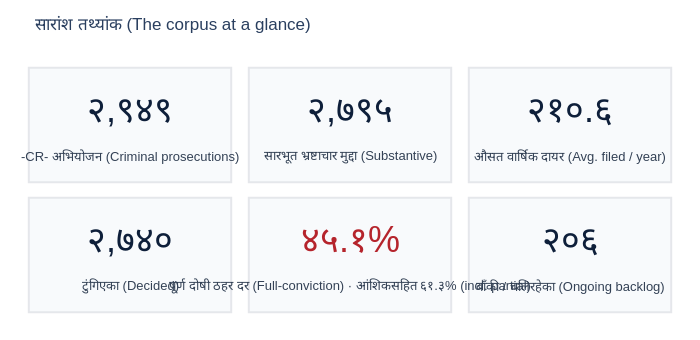

In [4]:
tiles = [
    ("-CR- अभियोजन (Criminal prosecutions)", dev(f"{ct['corpus_in_window']:,}")),
    ("सारभूत भ्रष्टाचार मुद्दा (Substantive)", dev(f"{ct['substantive']:,}")),
    ("औसत वार्षिक दायर (Avg. filed / year)", dev(f"{ct['avg_filed_per_year']:.1f}")),
    ("टुंगिएका (Decided)", dev(f"{ct['outcome_decided']:,}")),
    (f"पूर्ण दोषी ठहर दर (Full-conviction) · आंशिकसहित {dev(f'{AVG2:.1f}')}% (incl. partial)", dev(f"{AVG:.1f}") + "%"),
    ("बाँकी / चलिरहेका (Ongoing backlog)", dev(f"{ct['outcome_ongoing']:,}")),
]
fig = go.Figure()
fig.update_xaxes(visible=False, range=[0, 3]); fig.update_yaxes(visible=False, range=[0, 2])
for i, (lab, val) in enumerate(tiles):
    c, r = i % 3, 1 - i // 3
    accent = "%" in val
    fig.add_shape(type="rect", x0=c + 0.04, x1=c + 0.96, y0=r + 0.06, y1=r + 0.94,
                  line={"color": "#e5e7eb"}, fillcolor="#f8fafc")
    fig.add_annotation(x=c + 0.5, y=r + 0.62, text=val, showarrow=False,
                       font={"size": 36, "color": CRIMSON if accent else NAVY})
    fig.add_annotation(x=c + 0.5, y=r + 0.26, text=lab, showarrow=False, font={"size": 13, "color": "#334155"})
fig.update_layout(height=340, margin={"t": 60, "l": 20, "r": 20, "b": 20},
                  title="सारांश तथ्यांक (The corpus at a glance)")
fig

### How to read the verdict numbers — परिभाषा र इकाई

Every count below is a count of **cases (dockets), not people.** The Special Court records **one verdict
per case**, coded as one of three dispositions, and they form a mutually-exclusive partition of decided
cases:

- **दोषी ठहर (ṭhahar) — full conviction:** the charge is upheld.
- **आंशिक ठहर (āṃśik ṭhahar) — partial conviction:** the charge is upheld *in part*. **This is where a mixed
  bench lands** — when some accused are convicted and others acquitted, or conviction is on some counts /
  a reduced amount, the court records the *case* as आंशिक ठहर. We have **no per-defendant verdict** in the
  data, so we never split a case's defendants into convicted vs. acquitted.
- **सफाई (saphāī) — acquittal:** the accused are cleared / the case dismissed.

**"Convicted" = full (ठहर) only** is the headline throughout (a conservative bar). Because partial is a
real, common outcome, every figure also shows the **incl.-partial** rate alongside — so the court-wide
rate reads **45.1% full · 61.3% incl. partial** (1,230 / 442 / 1,056 full / partial / acquittal
across 2,728 decided cases). For contrast, the CIAA's own reported "success rate" (52.67%) counts full
+ partial together.

## 1. The funnel — about 0.2% of complaints end in a full conviction

Accountability is a pipeline, and almost all of the loss happens **before** a courtroom is involved.
Of the ~28,554 complaints **newly registered** at the CIAA in a single year (FY2081/82), only ~947
reach a full investigation, ~137 become prosecutions, and an estimated **~62 end in a full
conviction (~84 if partial convictions count)**. The steepest drop by far is at **intake screening**,
not adjudication.
*(Each stage counts that fiscal year's CIAA activity — a **throughput snapshot, not a traced cohort**:
this year's investigations and filings come from complaints of several years, and most of this year's
complaints resolve later. The top of the funnel is **newly registered** complaints only — it excludes
the ~8,500 prior-year backlog the CIAA also re-processed this year (total workload ~37,026), which
already entered as intake in their own registration year. Top three stages are CIAA annual-report
actuals; the conviction floor is **derived, not assumed** — the corpus full-conviction rate (45.1%)
applied to the filed count. Every stage is a count of **cases/prosecutions, not people**.)*

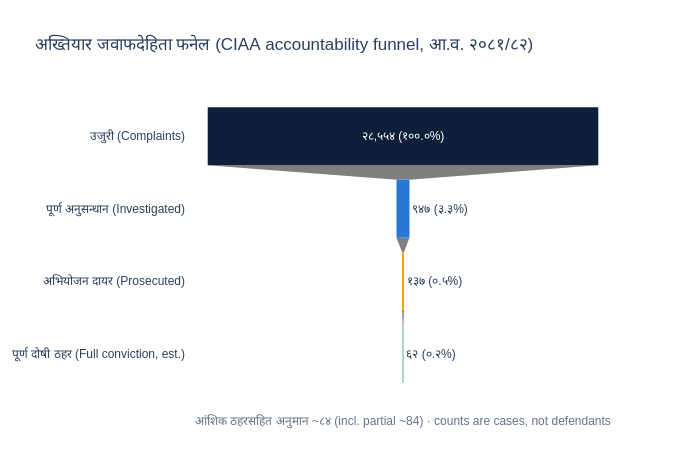

In [5]:
fn = funnel.copy()   # top 3 = CIAA actuals (assumptions.csv); convicted = derived (rate x filed)
lab = {"complaints": "उजुरी (Complaints)", "investigated": "पूर्ण अनुसन्धान (Investigated)",
       "filed": "अभियोजन दायर (Prosecuted)", "convicted": "पूर्ण दोषी ठहर (Full conviction, est.)"}
fn["label"] = fn.stage_key.map(lab).fillna(fn.stage_key)
top = fn["count"].iloc[0]
fn["text"] = [f"{dev(f'{c:,}')} ({dev(f'{c / top * 100:.1f}')}%)" for c in fn["count"]]
fig = go.Figure(go.Funnel(y=fn["label"], x=fn["count"], text=fn["text"], textinfo="text",
                          marker={"color": [NAVY, BLUE, AMBER, GREEN]}))
fig.add_annotation(x=0.5, xref="paper", y=-0.14, yref="paper", showarrow=False,
                   font={"size": 12, "color": "#64748b"},
                   text=f"आंशिक ठहरसहित अनुमान ~{dev(str(ct['funnel_convicted_incl_partial']))} "
                        f"(incl. partial ~{ct['funnel_convicted_incl_partial']}) · counts are cases, not defendants")
fig.update_layout(title="अख्तियार जवाफदेहिता फनेल (CIAA accountability funnel, आ.व. २०८१/८२)",
                  height=460, margin={"l": 180, "b": 70})
fig

The five-year picture is the same shape: **~107,000** newly registered complaints and **744**
prosecutions filed across FY2077/78–2081/82 — and in the reporting year alone the CIAA demanded
**Rs 6.02 bn** in damages. The court adjudicates a heavily pre-filtered sliver of the corruption that
gets reported.

## 2. Outcomes — fewer than half of decided prosecutions convict cleanly

Restricting to the corpus's decided cases with a clean disposition, the split is
**45% full conviction / 16% partial / 39% acquittal**. "Partial" (आंशिक ठहर) is where a mixed
outcome lands — some accused convicted and others acquitted, or conviction on some counts / a reduced
amount (these are *case* verdicts; the data carries no per-defendant outcome). Counting partial as a
win, **61% end in at least a partial conviction** — but **fewer than half convict cleanly.**

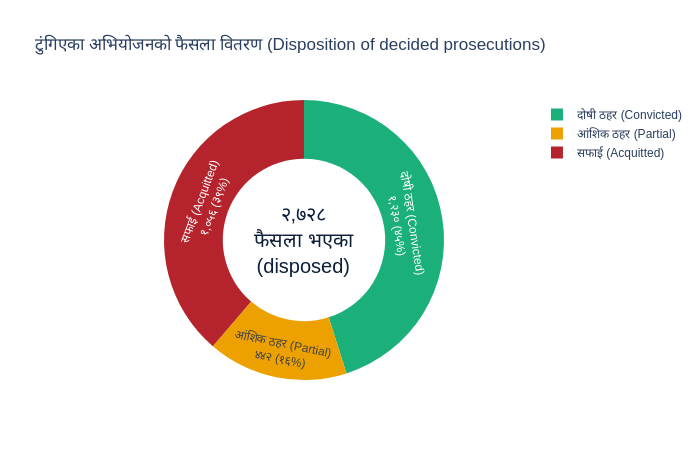

In [6]:
vals = [conv, part, acq]
labs = [L_CONV, L_PART, L_ACQ]
txt = [f"{L}<br>{dev(f'{v:,}')} ({dev(f'{v / clean * 100:.0f}')}%)" for L, v in zip(labs, vals)]
fig = go.Figure(go.Pie(labels=labs, values=vals, text=txt, textinfo="text", hole=0.58, sort=False,
                       direction="clockwise", marker={"colors": [GREEN, AMBER, CRIMSON]}))
fig.update_layout(title="टुंगिएका अभियोजनको फैसला वितरण (Disposition of decided prosecutions)",
                  annotations=[{"text": f"{dev(f'{clean:,}')}<br>फैसला भएका<br>(disposed)", "x": 0.5, "y": 0.5,
                                "showarrow": False, "font": {"size": 20, "color": NAVY}}],
                  height=460)
fig

## 3. What actually sticks — conviction depends on what was charged

The court average hides enormous spread. **Fake-credential** cases (नक्कली प्रमाण पत्र) convict at
~90%; the core financial-graft families — embezzlement, loss to government, illegal benefit — convict
far below average. Each bar is one offense family's decided cases split 100% Convicted / Partial /
Acquitted, sorted so the most-convicting charge is on top. The dashed line is the court-wide
conviction rate.

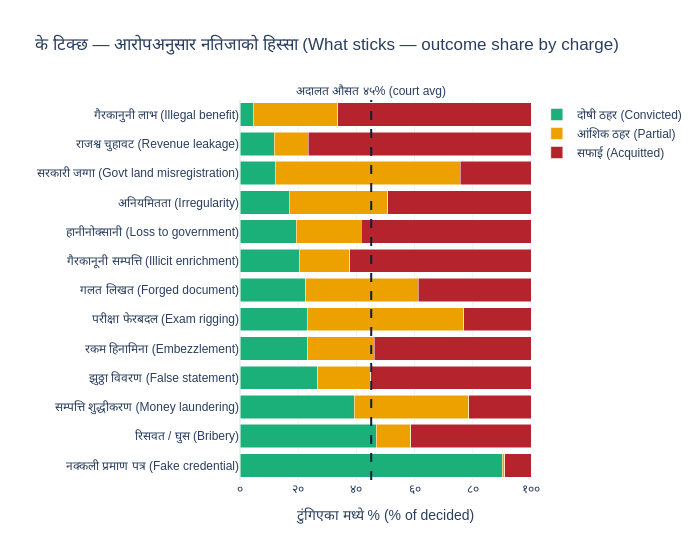

In [7]:
df = outcome_by_charge.copy()
df["total"] = df.convicted + df.partial + df.acquitted
df["conv_pct"] = df.convicted / df.total * 100
df = df.sort_values("conv_pct")   # ascending -> highest ends up at the top of a horizontal bar
df["label"] = df.charge_ne + " (" + df.charge_en + ")"
for c in ["convicted", "partial", "acquitted"]:
    df[c + "_pct"] = df[c] / df.total * 100
long = df.melt(id_vars="label", value_vars=["convicted_pct", "partial_pct", "acquitted_pct"],
               var_name="outcome", value_name="pct")
long["outcome"] = long.outcome.map({"convicted_pct": L_CONV, "partial_pct": L_PART, "acquitted_pct": L_ACQ})
fig = px.bar(long, y="label", x="pct", color="outcome", orientation="h", color_discrete_map=OUT,
             category_orders={"label": df.label.tolist(), "outcome": [L_CONV, L_PART, L_ACQ]},
             title="के टिक्छ — आरोपअनुसार नतिजाको हिस्सा (What sticks — outcome share by charge)")
fig.update_layout(barmode="stack", xaxis_title="टुंगिएका मध्ये % (% of decided)", yaxis_title="",
                  legend_title="", height=560)
pct_ticks(fig, "x")
fig.add_vline(x=AVG, line_dash="dash", line_color=NAVY,
              annotation_text=f"अदालत औसत {dev(f'{AVG:.0f}')}% (court avg)", annotation_position="top")
fig

## 4. Which bench you draw — full-conviction rate per justice

Outcomes vary almost as much by **who decides** as by what was charged. Each dot is one justice who
sat on ≥30 decided corruption cases; the x-position is that justice's full-conviction rate, the **dot
size is how many decisions** they wrote, and the colour band flags whether they convict more, near, or
less than the court average. The range runs from roughly **78% down to 21%**. *(Names are read verbatim
from public court records; caseload is not randomly assigned, so read this as a description of the
bench, not a ranking of rigour.)*

> **Why this differs from the website.** The published (all-years) page shows a wider **~25–85%** range
> with more justices. Because our corpus starts at **FY2069/70**, benches that sat mainly *before* that
> boundary fall outside this chart — including the court's early-era chairs, whose full-conviction rates
> ran to **~85%** but whose dockets were filed under the old pre-Shrawan-2069 numbering. One such chair
> has 37 lifetime decisions at ~86% but only 5 inside our window (below the ≥30 threshold), so he drops
> out. This isn't a data error; it's the same era-shift Section 5 describes — the window trades away the
> early high-conviction docket by design.

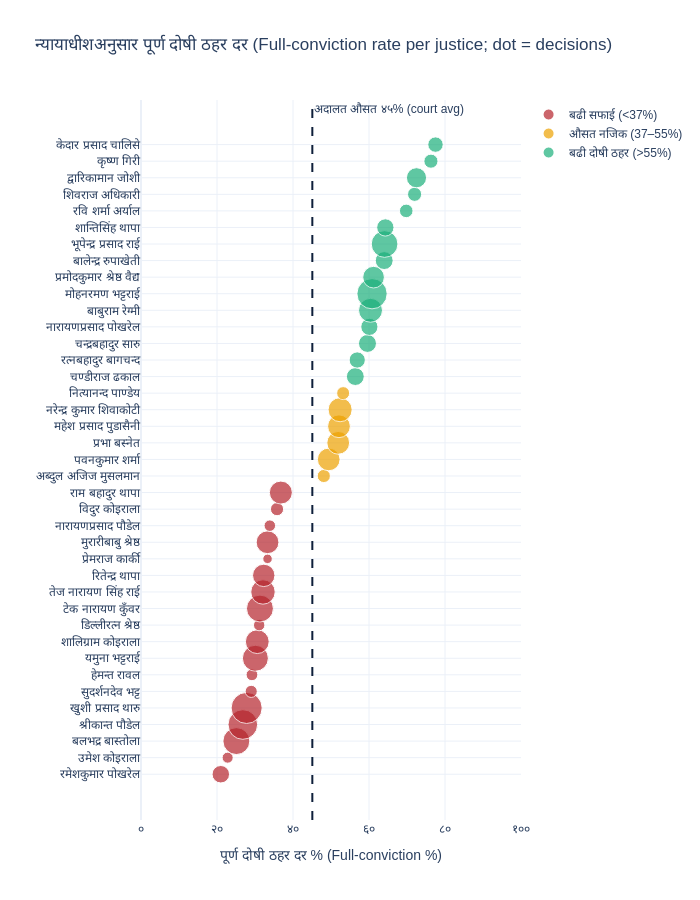

In [8]:
j = justices.sort_values("conviction_pct").copy()
B_HI, B_MID, B_LO = "बढी दोषी ठहर (>55%)", "औसत नजिक (37–55%)", "बढी सफाई (<37%)"
def band(p):
    return B_HI if p > 55 else (B_MID if p >= 37 else B_LO)
j["band"] = j.conviction_pct.map(band)
fig = px.scatter(j, x="conviction_pct", y="justice", size="decisions", color="band",
                 color_discrete_map={B_HI: GREEN, B_MID: AMBER, B_LO: CRIMSON}, size_max=22,
                 title="न्यायाधीशअनुसार पूर्ण दोषी ठहर दर (Full-conviction rate per justice; dot = decisions)",
                 hover_data={"decisions": True, "conviction_pct": ":.1f", "band": False})
fig.update_layout(xaxis_title="पूर्ण दोषी ठहर दर % (Full-conviction %)", yaxis_title="",
                  legend_title="", height=900)
pct_ticks(fig, "x")
fig.add_vline(x=AVG, line_dash="dash", line_color=NAVY,
              annotation_text=f"अदालत औसत {dev(f'{AVG:.0f}')}% (court avg)")
fig

## 5. Over time — the court convicts far less than it used to

Grouped by **verdict** fiscal year. In the early years the court convicted 70–86% of what it decided;
by FY2078/79 that collapses to ~14% as a wave of acquittals lands, and it only partly recovers. Watch
the crimson **Acquitted** line cross above **Convicted**. (Smooth spline lines, matching the site.)

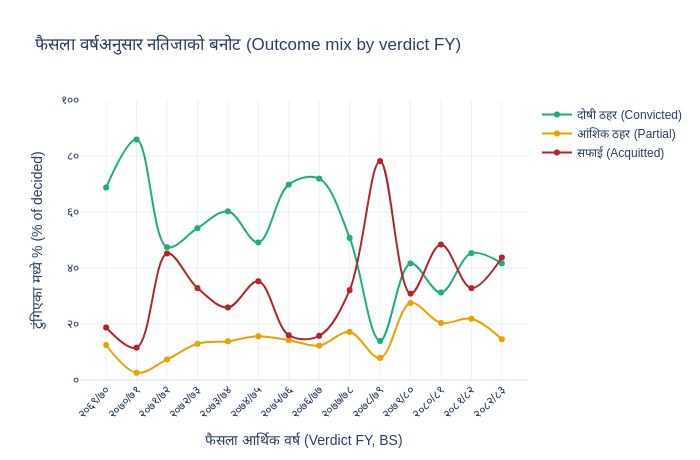

In [9]:
v = verdict_by_year.copy()
v["total"] = v.convicted + v.partial + v.acquitted
for c in ["convicted", "partial", "acquitted"]:
    v[c + "_pct"] = v[c] / v.total * 100
long = v.melt(id_vars="fiscal_year", value_vars=["convicted_pct", "partial_pct", "acquitted_pct"],
              var_name="outcome", value_name="pct")
long["outcome"] = long.outcome.map({"convicted_pct": L_CONV, "partial_pct": L_PART, "acquitted_pct": L_ACQ})
fig = px.line(long, x="fiscal_year", y="pct", color="outcome", markers=True, color_discrete_map=OUT,
              category_orders={"outcome": [L_CONV, L_PART, L_ACQ]}, line_shape="spline",
              title="फैसला वर्षअनुसार नतिजाको बनोट (Outcome mix by verdict FY)")
fig.update_layout(yaxis_title="टुंगिएका मध्ये % (% of decided)", legend_title="", height=460)
fy_axis(fig, v.fiscal_year, AX_VFY); pct_ticks(fig, "y")
fig

**Is the decline real, or just an easier docket drying up?** Fake-credential cases are near-automatic
convictions; as the court works through them, the *headline rate* falls even if the court is no less
willing to convict. So we strip them out. The dashed **core-graft** line (everything except fake
credential) is **roughly flat throughout — a ~30% band** — early cohorts and recent ones convict
substantive corruption at about the same rate. So the all-charges line falls *toward* that flat core line
as the easy wins leave: the decline is **mostly a docket-mix shift**, not the court convicting serious
graft any less. The sharp single-year dips (आ.व. २०७८/७९, २०८०/८१) are acquittal spikes, not a trend.

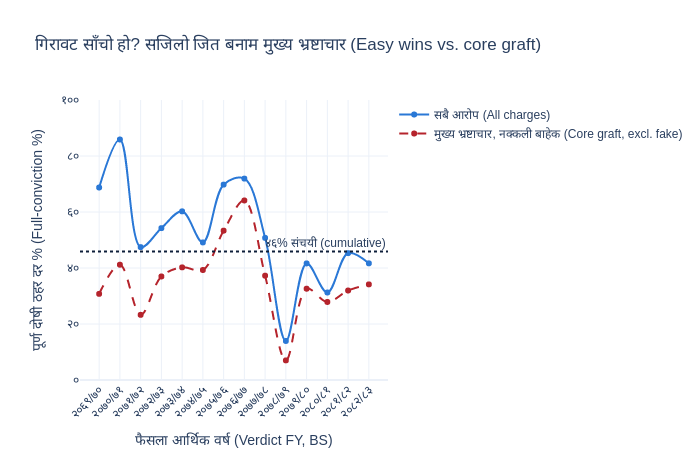

In [10]:
v["core_disp"] = v.total - v.fake_disposed
v["core_conv"] = v.convicted - v.fake_convicted
v["all_pct"] = v.convicted / v.total * 100
v["core_pct"] = v.core_conv / v.core_disp * 100
cum = v.convicted.sum() / v.total.sum() * 100
fig = go.Figure()
fig.add_trace(go.Scatter(x=v.fiscal_year, y=v.all_pct, mode="lines+markers", name="सबै आरोप (All charges)",
                         line={"color": BLUE, "shape": "spline"}))
fig.add_trace(go.Scatter(x=v.fiscal_year, y=v.core_pct, mode="lines+markers",
                         name="मुख्य भ्रष्टाचार, नक्कली बाहेक (Core graft, excl. fake)",
                         line={"color": CRIMSON, "dash": "dash", "shape": "spline"}))
fig.add_hline(y=cum, line_dash="dot", line_color=NAVY, annotation_text=f"{dev(f'{cum:.0f}')}% संचयी (cumulative)")
fig.update_layout(title="गिरावट साँचो हो? सजिलो जित बनाम मुख्य भ्रष्टाचार (Easy wins vs. core graft)",
                  yaxis_title="पूर्ण दोषी ठहर दर % (Full-conviction %)", legend_title="", height=460)
fy_axis(fig, v.fiscal_year, AX_VFY); pct_ticks(fig, "y")
fig

*Beyond the site:* the same story in **absolute volume**. The acquittal surge of FY2078/79–2080/81
isn't a small-sample artefact — it's a genuine spike in the number of cases decided, dominated by
acquittals. (Percentages alone can hide whether a rate moved because the numerator fell or the
denominator grew; this settles it.)

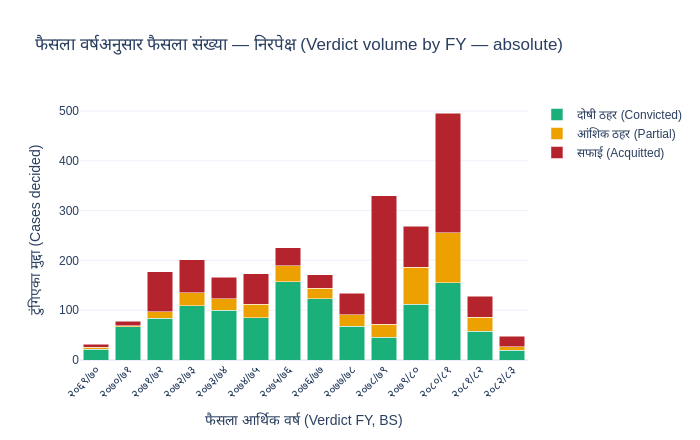

In [11]:
long = verdict_by_year.melt(id_vars="fiscal_year", value_vars=["convicted", "partial", "acquitted"],
                            var_name="outcome", value_name="cases")
long["outcome"] = long.outcome.map({"convicted": L_CONV, "partial": L_PART, "acquitted": L_ACQ})
fig = px.bar(long, x="fiscal_year", y="cases", color="outcome", color_discrete_map=OUT,
             category_orders={"outcome": [L_CONV, L_PART, L_ACQ]},
             title="फैसला वर्षअनुसार फैसला संख्या — निरपेक्ष (Verdict volume by FY — absolute)")
fig.update_layout(barmode="stack", yaxis_title="टुंगिएका मुद्दा (Cases decided)", legend_title="", height=440)
fy_axis(fig, verdict_by_year.fiscal_year, AX_VFY)
fig

## Who was in charge — a reference timeline

Purely for **context** when reading the trends above: the heads of government and the CIAA's chief
commissioners across the same period, with tenures in both **English (AD)** and **Nepali (BS)** dates.
This is a neutral institutional timeline — *no causal claim* is implied between any office-holder and the
case outcomes; it is a reference so you can line leadership changes up against the filing and conviction
series. The shaded band is the corpus window (FY2069/70–2082/83). Note the CIAA chief-commissioner
**vacancy after Oct 2016** — led only in an officiating capacity until Feb 2021.

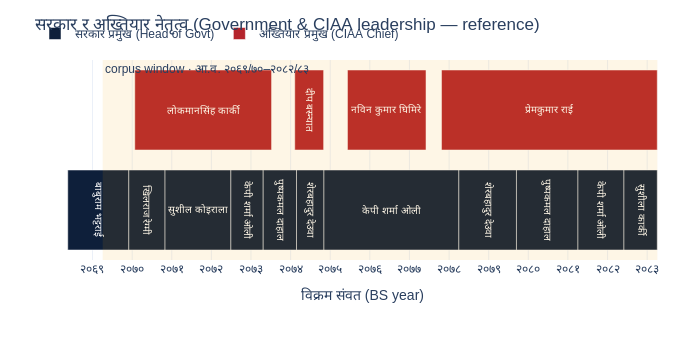

In [12]:
lead = leadership.copy()
lead["start"] = pd.to_datetime(lead.start_ad)
lead["end"] = pd.to_datetime(lead.end_ad)
LANE = {"Head of Government": "सरकार प्रमुख (Head of Govt)",
        "CIAA Chief Commissioner": "अख्तियार प्रमुख (CIAA Chief)"}
lead["lane_lbl"] = lead.lane.map(LANE)
lead["holder"] = lead.name_ne + " (" + lead.name_en + ")"
lead["AD"] = lead.start_ad + " → " + lead.end_ad
lead["BS"] = lead.start_bs.map(dev) + " → " + lead.end_bs.map(dev)
fig = px.timeline(lead, x_start="start", x_end="end", y="lane_lbl", color="lane_lbl", text="name_ne",
                  color_discrete_map={LANE["Head of Government"]: NAVY, LANE["CIAA Chief Commissioner"]: CRIMSON},
                  hover_name="holder", hover_data={"AD": True, "BS": True, "status": True,
                                                   "lane_lbl": False, "name_ne": False})
# BS (Bikram Sambat) x-axis: bars keep real AD dates for width; ticks = each BS new year (Baisakh 1),
# with the AD position computed by the nepali_datetime library (cd.bs_to_ad) — nothing hardcoded.
bs_years = range(2069, 2084)
fig.update_xaxes(title="विक्रम संवत (BS year)", tickmode="array",
                 tickvals=pd.to_datetime([cd.bs_to_ad(f"{y}-01-01") for y in bs_years]),
                 ticktext=[dev(y) for y in bs_years])
fig.update_yaxes(showticklabels=False, title="", autorange="reversed")   # lane names -> legend, saves width
fig.update_traces(textposition="inside", insidetextanchor="middle", textfont_size=10)
fig.add_vrect(x0="2012-07-16", x1="2026-07-17", fillcolor=AMBER, opacity=0.10, line_width=0,
              annotation_text="corpus window · आ.व. २०६९/७०–२०८२/८३", annotation_position="top left")
fig.update_layout(title="सरकार र अख्तियार नेतृत्व (Government & CIAA leadership — reference)",
                  height=340, margin={"l": 10, "r": 10}, uniformtext_minsize=8, uniformtext_mode="hide",
                  legend={"orientation": "h", "yanchor": "bottom", "y": 1.06, "x": 0, "title": ""})
fig

Exact tenures, both calendars (BS dates in Devanagari) — the same table the timeline draws from:

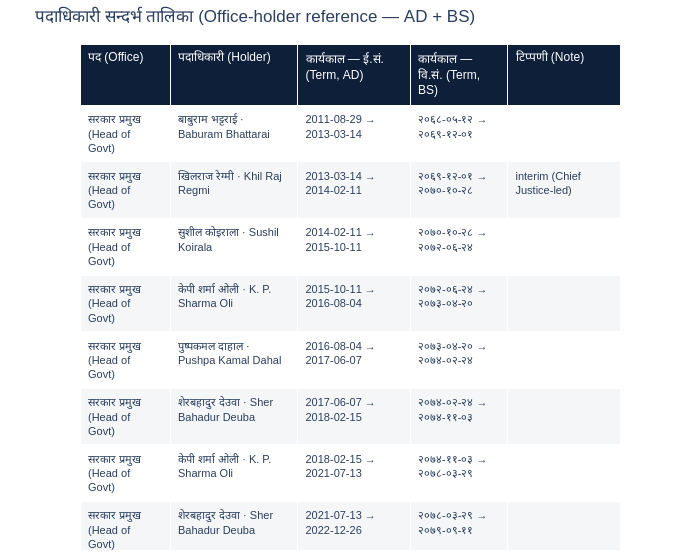

In [13]:
hdr = ["पद (Office)", "पदाधिकारी (Holder)", "कार्यकाल — ई.सं. (Term, AD)", "कार्यकाल — वि.सं. (Term, BS)", "टिप्पणी (Note)"]
office = lead.lane.map({"Head of Government": "सरकार प्रमुख (Head of Govt)", "CIAA Chief Commissioner": "अख्तियार प्रमुख (CIAA Chief)"})
holder = lead.name_ne + " · " + lead.name_en
rc = ["#f5f6f8" if i % 2 else "white" for i in range(len(lead))]
fig = go.Figure(go.Table(
    columnwidth=[24, 34, 30, 26, 30],
    header=dict(values=hdr, fill_color=NAVY, font={"color": "white", "size": 12}, align="left", height=32),
    cells=dict(values=[office, holder, lead.AD, lead.BS, lead.status], fill_color=[rc] * 5,
               align="left", font={"size": 11}, height=24)))
fig.update_layout(title="पदाधिकारी सन्दर्भ तालिका (Office-holder reference — AD + BS)",
                  height=560, margin={"t": 44, "b": 10})
fig

## 6. Volume & pace — what flows through the court, and how long it takes

### Cases filed vs. decided, by year
Filings (by registration FY) against dispositions (by verdict FY). The court spent years filing faster
than it cleared, then in FY2078/79–2080/81 cleared faster than it filed — the mechanical cause of the
acquittal-heavy disposition wave above.

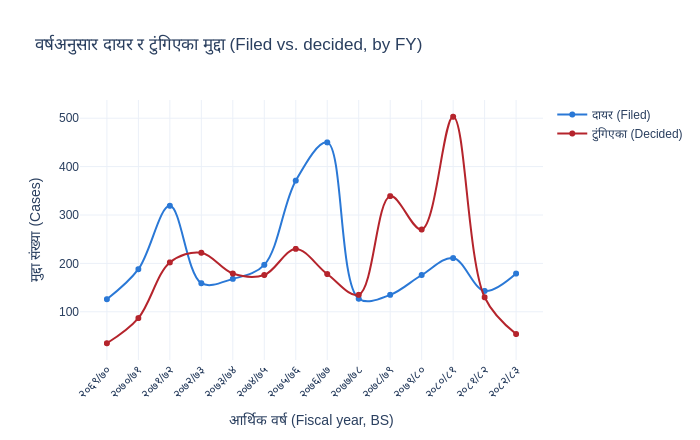

In [14]:
d = filed_vs_decided_by_year
fig = go.Figure()
fig.add_trace(go.Scatter(x=d.fiscal_year, y=d.filed, mode="lines+markers", name="दायर (Filed)",
                         line={"color": BLUE, "shape": "spline"}))
fig.add_trace(go.Scatter(x=d.fiscal_year, y=d.decided, mode="lines+markers", name="टुंगिएका (Decided)",
                         line={"color": CRIMSON, "shape": "spline"}))
fig.update_layout(title="वर्षअनुसार दायर र टुंगिएका मुद्दा (Filed vs. decided, by FY)",
                  yaxis_title=AX_CASE, legend_title="", height=440)
fy_axis(fig, d.fiscal_year)
fig

### The backlog
Two views. First, the **standing backlog** — the total open caseload at each fiscal year-end,
accumulated as net (filed − decided). It builds through FY2076/77 to a peak of ~667 open cases, then
the FY2078/79–2080/81 clearance wave draws it down before it ticks back up. It ends near the corpus's
current **169 ongoing** cases — a useful consistency check.

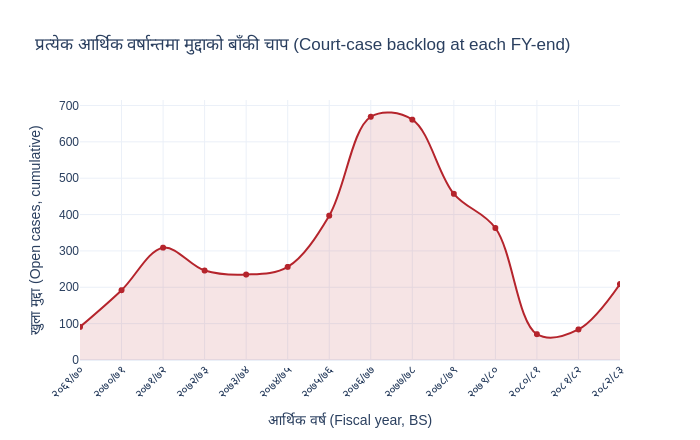

In [15]:
b = filed_vs_decided_by_year.copy()
b["standing"] = (b.filed - b.decided).cumsum()
fig = go.Figure(go.Scatter(x=b.fiscal_year, y=b.standing, mode="lines+markers", name="बाँकी चाप (Standing backlog)",
                           fill="tozeroy", fillcolor="rgba(181,36,44,0.12)",
                           line={"color": CRIMSON, "shape": "spline"}))
fig.update_layout(title="प्रत्येक आर्थिक वर्षान्तमा मुद्दाको बाँकी चाप (Court-case backlog at each FY-end)",
                  yaxis_title="खुला मुद्दा (Open cases, cumulative)", height=440)
fy_axis(fig, b.fiscal_year)
fig

Second, **which cohorts are stuck**: cases from each filing cohort still awaiting a verdict today.
It's ~zero through FY2076/77; the recent cohorts (FY2081/82–2082/83) carry almost the entire open load.

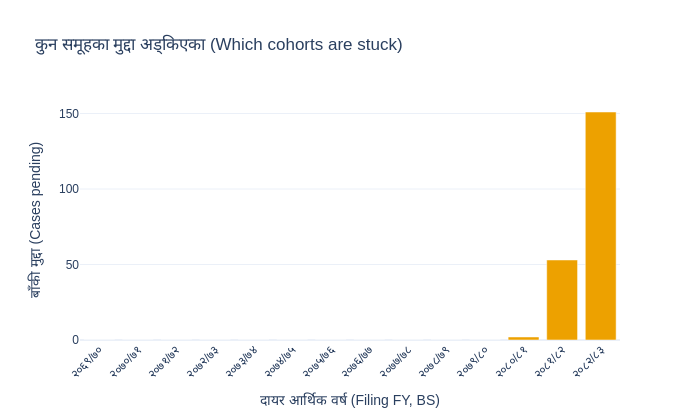

In [16]:
fig = px.bar(cohorts, x="fiscal_year", y="pending",
             title="कुन समूहका मुद्दा अड्किएका (Which cohorts are stuck)")
fig.update_traces(marker_color=AMBER)
fig.update_layout(yaxis_title="बाँकी मुद्दा (Cases pending)", height=420)
fy_axis(fig, cohorts.fiscal_year, AX_FFY)
fig

### Time to verdict, by filing cohort
Median months from registration to verdict, per **filing** cohort (grouping by verdict year would
flatter slow cases). Cohorts through **FY2079/80** are essentially fully decided, so their medians are
trustworthy (solid); later cohorts are still open and only the fast cases have landed, biasing them low
(dashed). The complete cohorts peak at **~30 months** for FY2076/77.

*(The site squeezes this and the backlog onto one dual-axis chart. A single y-axis per chart is
clearer and honest about scale, so we split them.)*

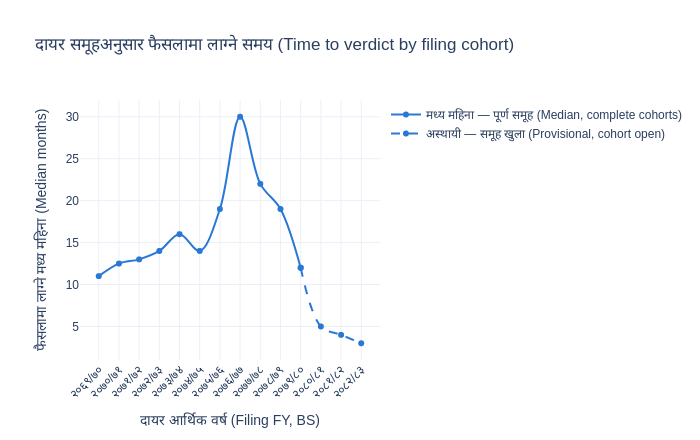

In [17]:
c = cohorts.copy()
complete = c[c.fiscal_year <= "2079/80"]
prov = c[c.fiscal_year >= "2079/80"]
fig = go.Figure()
fig.add_trace(go.Scatter(x=complete.fiscal_year, y=complete.median_months, mode="lines+markers",
                         name="मध्य महिना — पूर्ण समूह (Median, complete cohorts)",
                         line={"color": BLUE, "shape": "spline"}))
fig.add_trace(go.Scatter(x=prov.fiscal_year, y=prov.median_months, mode="lines+markers",
                         name="अस्थायी — समूह खुला (Provisional, cohort open)",
                         line={"color": BLUE, "dash": "dash", "shape": "spline"}))
fig.update_layout(title="दायर समूहअनुसार फैसलामा लाग्ने समय (Time to verdict by filing cohort)",
                  yaxis_title="फैसलामा लाग्ने मध्य महिना (Median months)", legend_title="", height=440)
fy_axis(fig, c.fiscal_year, AX_FFY)
fig

### The charge mix
What the state actually prosecutes, over the whole window. **Bribery** and **fake-credential** cases
dominate the docket; the heavier financial-graft categories are a minority by count.

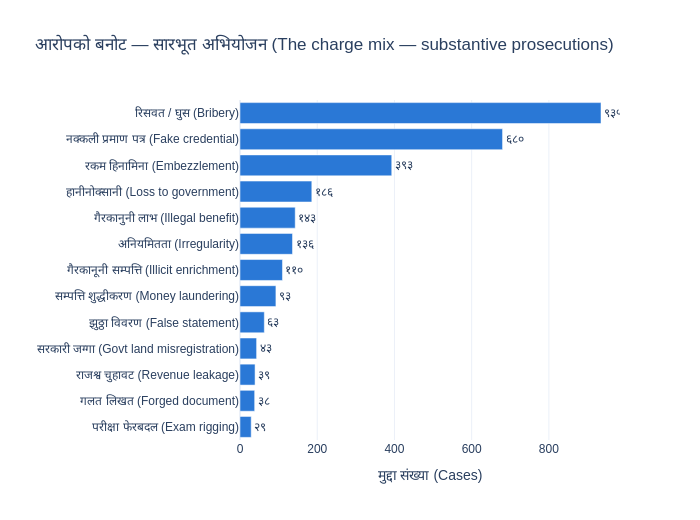

In [18]:
m = offense_mix.sort_values("count").copy()
m["label"] = m.offense_ne + " (" + m.offense_en + ")"
fig = px.bar(m, y="label", x="count", orientation="h", text=[dev(f"{c:,}") for c in m["count"]],
             title="आरोपको बनोट — सारभूत अभियोजन (The charge mix — substantive prosecutions)")
fig.update_traces(marker_color=BLUE, textposition="outside")
fig.update_layout(xaxis_title=AX_CASE, yaxis_title="", height=520)
fig

### How the charge mix shifted, by year
The crimson **fake-credential** band dominates the early docket and thins after ~FY2076/77; the newer
**illegal-benefit** charge and **loss to government** grow. Click a family in the legend to isolate it.

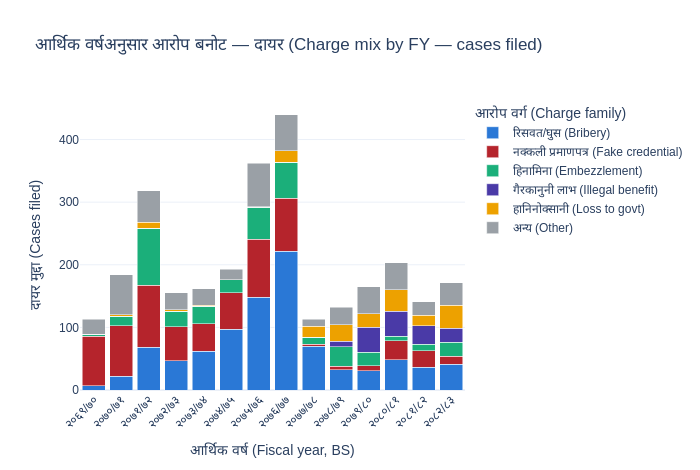

In [19]:
fams = ["bribery", "fake", "embezzlement", "benefit", "loss", "other"]
long = charge_mix_by_year.melt(id_vars="fiscal_year", value_vars=fams, var_name="fam", value_name="cases")
long["family"] = long.fam.map(FAM_NE)
order = [FAM_NE[f] for f in fams]
fig = px.bar(long, x="fiscal_year", y="cases", color="family", color_discrete_map=CLR_NE,
             category_orders={"family": order},
             title="आर्थिक वर्षअनुसार आरोप बनोट — दायर (Charge mix by FY — cases filed)")
fig.update_layout(barmode="stack", legend_title="आरोप वर्ग (Charge family)",
                  yaxis_title="दायर मुद्दा (Cases filed)", bargap=0.15, height=470)
fy_axis(fig, charge_mix_by_year.fiscal_year)
fig

Same chart as **100% share** — composition independent of volume. The fake-credential collapse and the illegal-benefit rise read even more clearly here.

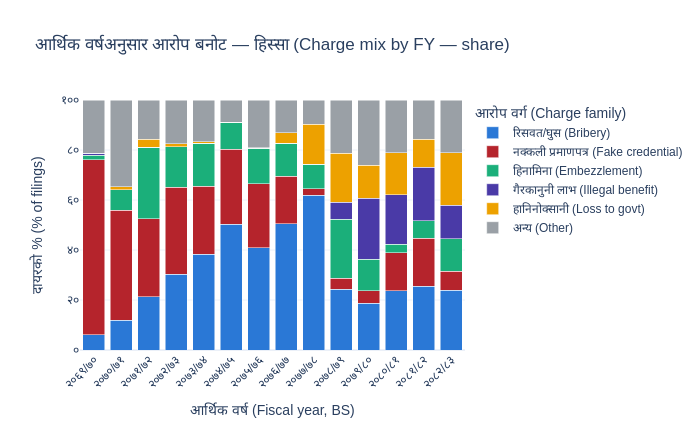

In [20]:
fig = px.bar(long, x="fiscal_year", y="cases", color="family", color_discrete_map=CLR_NE,
             category_orders={"family": order},
             title="आर्थिक वर्षअनुसार आरोप बनोट — हिस्सा (Charge mix by FY — share)")
fig.update_layout(barmode="stack", barnorm="percent", legend_title="आरोप वर्ग (Charge family)",
                  yaxis_title="दायरको % (% of filings)", height=430)
fy_axis(fig, charge_mix_by_year.fiscal_year); pct_ticks(fig, "y")
fig

### When cases are filed, by Nepali month
Mean filings per Nepali month across the 14 fiscal years; error bars are ±1 sample SD (year-to-year
variability). Filings peak at the **Ashadh** fiscal year-end rush and trough in **Kartik**
(Dashain/Tihar).

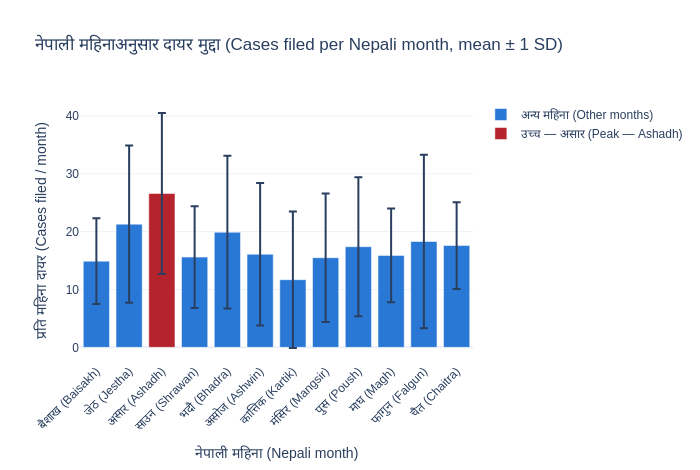

In [21]:
df = filed_by_month.copy()
df["label"] = [f"{ne} ({en})" for ne, en in zip(NE_MONTHS, df.month_name)]
peak = int(df["mean"].idxmax())
L_PEAK, L_OTHER = "उच्च — असार (Peak — Ashadh)", "अन्य महिना (Other months)"
df["role"] = [L_PEAK if i == peak else L_OTHER for i in df.index]
fig = px.bar(df, x="label", y="mean", error_y="sd", color="role",
             color_discrete_map={L_PEAK: CRIMSON, L_OTHER: BLUE},
             category_orders={"label": df.label.tolist()},
             title="नेपाली महिनाअनुसार दायर मुद्दा (Cases filed per Nepali month, mean ± 1 SD)")
fig.update_layout(xaxis_title="नेपाली महिना (Nepali month)",
                  yaxis_title="प्रति महिना दायर (Cases filed / month)", legend_title="", height=470)
fig.update_xaxes(tickangle=-45)
fig

## 7. Where the gap is — attrition concentrates at the CIAA stage, then goes dark

Putting the sections together, the accountability pipeline leaks unevenly:

1. **Intake & screening (CIAA).** The dominant loss. ~28,554 newly registered complaints → ~947 full
   investigations in a year (Section 1). Whatever the mix of frivolous complaints and under-resourced
   screening, this is where the funnel narrows most.
2. **Charging strategy (CIAA).** Of what's prosecuted, the docket leans on **bribery** and
   **fake-credential** charges (Sections 3, 6) — the latter near-automatic convictions. Heavier graft
   is a smaller share and converts worse.
3. **Adjudication (Special Court).** Fewer than half of decided prosecutions convict cleanly
   (Section 2); the headline rate has fallen over time, though mostly as easy fake-credential wins left
   the docket rather than core graft convicting less (Section 5); and the backlog is climbing (Section 6).
4. **Appeal (Supreme Court) — dark.** The mirror captures **zero** corruption-appeal dispositions with a
   usable outcome, so reversal/upholding rates at the apex court **cannot be computed here**.
5. **Recovery & sanction — dark.** Whether damages are actually recovered and penalties enforced is not
   in the court record at all.

The two stages we most want for a full accountability story — appeal and recovery — are exactly the two
we can't measure from this data.

## 8. Methodology & data gaps

**Source of truth.** Everything sits in one `dataset/` folder: `cases.csv` (the 2,949 `-CR-` corpus),
`hearings.csv`, `entities.csv`, and `assumptions.csv` (external CIAA constants, with a `source_url` per
figure). The court tables are pulled from Jawafdehi's internal read-only query API (a guarded,
`SELECT`-only proxy requiring the least-privilege `ReadOnly` role) over the frozen Special Court mirror — the raw `-CR-`
pages are paginated, scoped to the corpus, and written to those source files (which are themselves the
cache — normal runs read them with no API call; only a refresh re-pulls). Every
result table (offense mix, outcomes, trends, …) is then **derived in pandas** from those source tables
(`corpus_data.py`); nothing else is a query and no results are stored. A reader can audit the whole
chain: source data + assumptions → results.

**Corpus & fiscal-year axis.** `-CR-` register, filed in `[2069-04-01, 2083-04-01)` — no plaintiff
filter (the register defines it; the ~34 individual-plaintiff `निर्णय वदर` petitions fall in `other`).
By-year charts group by **fiscal year** (`YYYY/YY`, rendered `२०६९/७०`). Filing-based series (charge
mix, filed, cohorts, backlog) key on the filing FY; verdict-based series (outcome trend, fake/core
split) key on the verdict FY — so the same case can sit in different bars across charts because they
count different **events**.

**Display.** Labels are Nepali with the English in brackets; figures use Devanagari numerals. Auto
numeric count-axes and hover tooltips keep ASCII digits (Plotly can't localize those without
hardcoding every tick), so a few readouts remain in Western numerals.

**Parsing quirks.** Verdict dates live inside `case_status` as `फैसला (मिती: YYYY/MM/DD)` in Devanagari
digits (the `verdict_*` columns are NULL); the bench string in `judge_names` is newline-separated and
split client-side. "Clean disposition" counts cases with a `decision_type` of ठहर / आंशिक ठहर / सफाई
(2,728); `decided` counts cases whose `case_status` starts फैसला (2,740). The two differ in
both directions: a few cases carry a verdict-hearing disposition without a फैसला `case_status`, and —
more so since the mirror's latest backfill — some decided cases have hearing rows whose `decision_type`
and `judge_names` were never populated, so they show as decided but contribute no verdict. The
disposition donut and the "Decided" tile therefore rest on slightly different denominators, by design.

**Verdict provenance — every rate here is court-sourced.** A disposition normally reaches the mirror
because the court published it on a daily cause list. Cases that arrived another way — chiefly the
2026-07 register backfill, which recovered dockets the court had issued but never listed publicly —
can be marked decided while carrying no `decision_type` at all. For most of those the court publishes
the full judgment (faisala), so the disposition can be recovered by reading it; `hearings.csv` flags
any such row with `verdict_derived = True`, alongside the model, the source document and the quoted
operative clause. **Those rows are dropped before any number on this page is computed**
(69 currently excluded, reported as `verdicts_model_derived_excluded`). Reading a verdict out
of the court's own judgment is defensible, but it is not the court's coding, and a published conviction
rate should not blend the two without saying so.

**Known gaps.** No appellate layer (Supreme Court corruption appeals return no usable dispositions);
weak defendant resolution (only 607 of the 8,321 distinct defendants in the corpus resolve to a
canonical entity — from `entities.csv`); CIAA figures are OCR/vision reads off the annual-report PDFs
(`ciaa-annual-reports/`), captured as assumptions and used only for the funnel top and five-year context.

**Reproduce.** Reading needs nothing — the dataset ships with the repo. To re-pull it from the live API,
flip `REFRESH_FROM_API = True` and re-run, or from the CLI: `python gen_dataset.py`. Either way you approve
a short code at auth.jawafdehi.org/device in any browser; the token carries your own roles, and the query
plane needs `ReadOnly` (a 403 there means the account lacks it — logging in again won't help).